   END-TO-END RAINFALL PIPELINE
   Stage 1 : PrithviWxC  →  0.5° precipitation
   Stage 2 : U-Net       →  downscale India to 0.1°
MERRA-2 3-hourly steps: 00 / 03 / 06 / 09 / 12 / 15 / 18 / 21



Date (YYYY-MM-DD):  2020-09-17
Hour (00/03/06/09/12/15/18/21):  18



>>> Input    : 2020-09-17 18:00 UTC
>>> Context  : t-3h=2020-09-17 15:00  |  t-6h=2020-09-17 12:00 UTC
>>> Predicts : 2020-09-17 21:00 UTC  (+3 h lead)

Device: cuda
  [GPU start] allocated=0.0GB  reserved=0.1GB

  STAGE 1 : PrithviWxC  →  0.5° precipitation


Fetching ... files: 0it [00:00, ?it/s]

✅ Data downloaded.

Building dataset:  2020-09-17T00:00:00  →  2020-09-17T23:59:59
Dataset: 6 samples

Sample index: 5  (2020-09-17 18:00  →  2020-09-17 21:00 UTC)

sur_vals: (21, 2, 361, 576)  [n_vars, n_times, H, W]
✅ Scalers loaded.
✅ PrithviWxC loaded  (epoch=9, val_loss=26.4640)
  [GPU after Stage-1 load] allocated=20.8GB  reserved=20.8GB
  [GPU after Stage-1 inference] allocated=21.3GB  reserved=36.0GB

Freeing Stage-1 from GPU memory…
  [GPU after Stage-1 cleanup] allocated=0.0GB  reserved=0.1GB

Stage-1 global : (360, 576)  min=0.0000  max=60.8551  mm/3h
Stage-1 India  : (63, 47)  min=0.0000  max=22.8321  mean=0.9580  mm/3h

Met vars cropped to India (63×47):
  U10M  : (63, 47)  min=-5.89  max=9.78
  V10M  : (63, 47)  min=-8.66  max=7.88
  T2M   : (63, 47)  min=270.38  max=313.83
  QV2M  : (63, 47)  min=0.00  max=0.02
  PS    : (63, 47)  min=51802.73  max=101087.07

  STAGE 2 : U-Net  →  downscale India to 0.1°
✅ U-Net loaded.
  [GPU after Stage-2 load] allocated=0.1GB  reserve

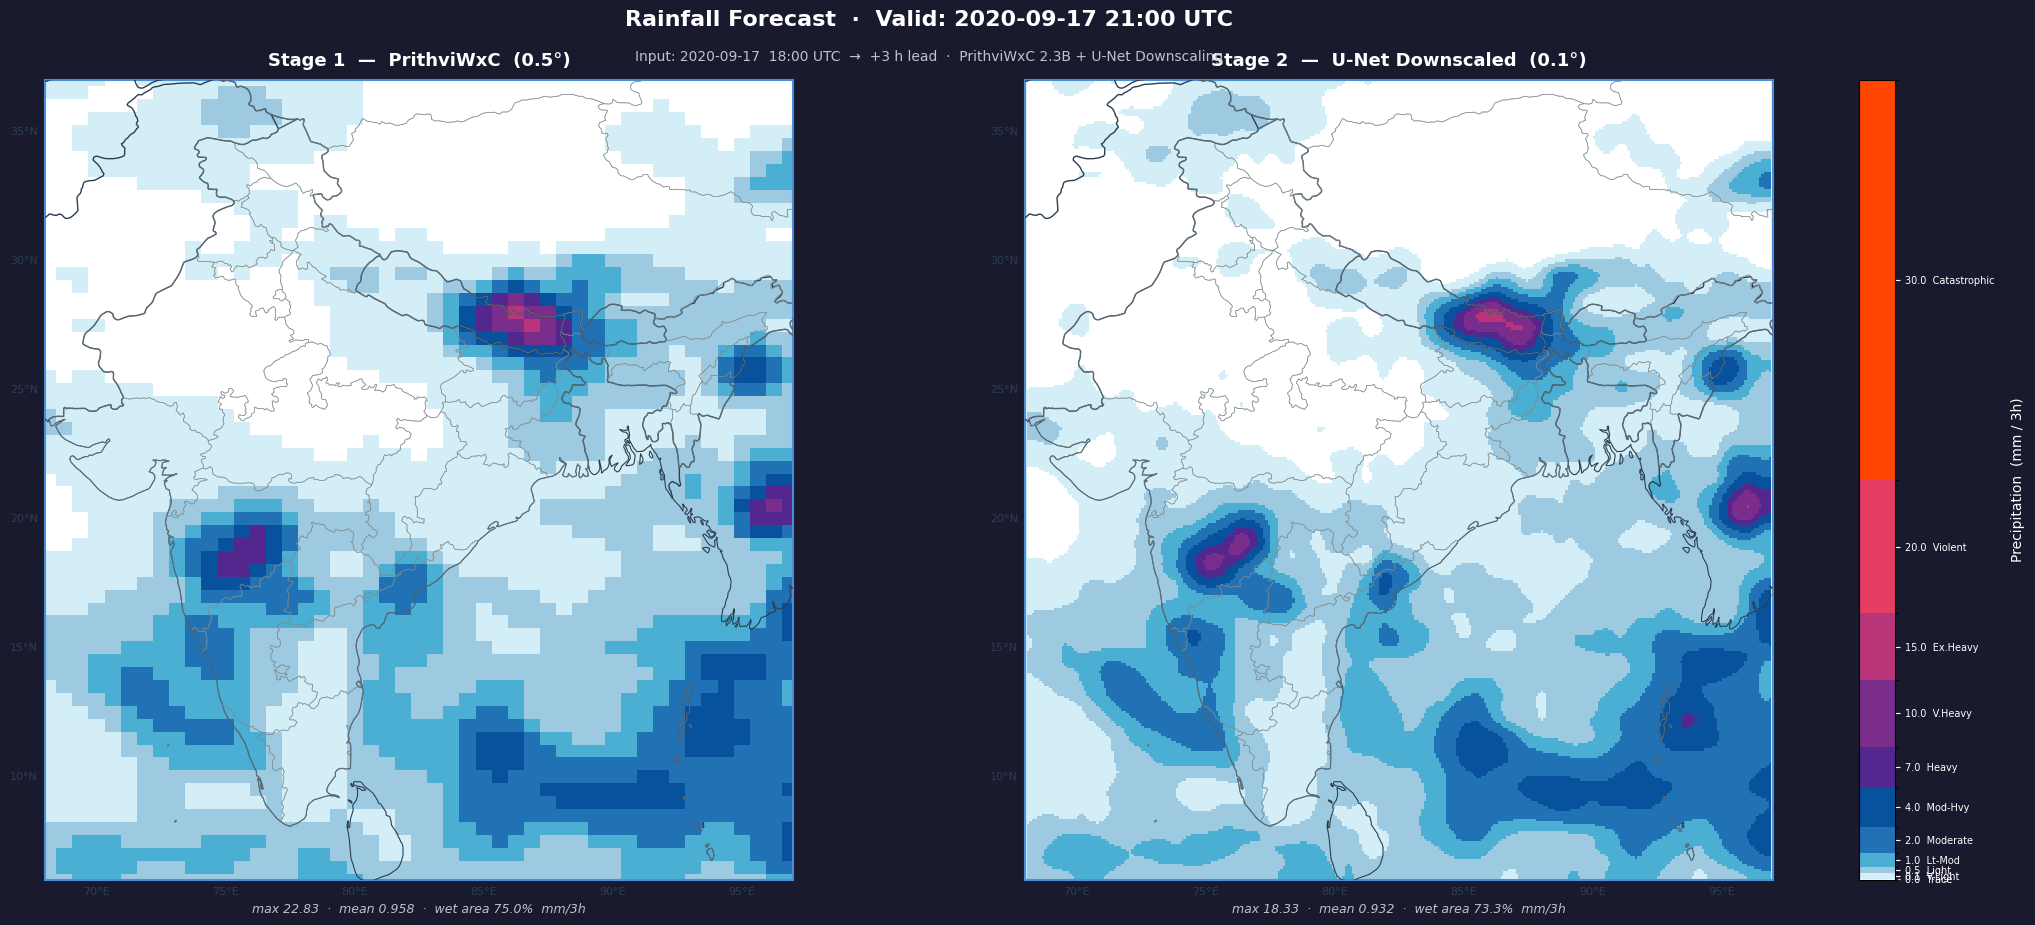

✅ Figure saved → pipeline_2020-09-17_18h.png
✅ Raw arrays saved  (mm/3h, unsmoothed)

  PIPELINE COMPLETE
  Stage-1 global : (360, 576)  max=60.855 mm/3h
  Stage-1 India  : (63, 47)   max=22.832 mm/3h
  Stage-2 India  : (320, 300)         max=18.334 mm/3h


In [ ]:
"""
End-to-End Rainfall Prediction Pipeline
========================================
STAGE 1 : PrithviWxC  →  predict precipitation at 0.5° resolution
STAGE 2 : U-Net (Bernoulli-Gamma)  →  downscale 0.5° to 0.1° resolution

VISUALISATION SMOOTHING:
  Raw model outputs are kept intact for saving (no data manipulation).
  For display only, a Gaussian filter softens abrupt spatial transitions,
  making rainfall gradients look physically realistic.
  Smoothing sigma is tuned per stage:
    Stage-1 (0.5°, coarser) : sigma=0.8  (light touch)
    Stage-2 (0.1°, finer)   : sigma=1.2  (slightly more since 5x denser grid)
"""

from pathlib import Path
import sys
import gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from datetime import datetime, timedelta
from huggingface_hub import snapshot_download
from scipy.stats import iqr as scipy_iqr

# dir_prithvi = Path("/kaggle/input/datasets/ajaypaliwal/prithvi-directory")
# sys.path.append(str(dir_prithvi))

from PrithviWxC.model import PrithviWxC
from PrithviWxC.dataloaders.merra2 import Merra2Dataset, preproc
from PrithviWxC.dataloaders.merra2 import (
    input_scalers, output_scalers, static_input_scalers,
)

# =============================================================================
# MERRA-2 GRID
# =============================================================================

MERRA2_LAT = np.arange(-90.0, 90.0,  0.5)
MERRA2_LON = np.arange(-180.0, 180.0, 0.625)

INDIA_LAT_MIN, INDIA_LAT_MAX = 6.0,  37.0
INDIA_LON_MIN, INDIA_LON_MAX = 68.0, 97.0

lat_idx   = np.where((MERRA2_LAT >= INDIA_LAT_MIN) & (MERRA2_LAT <= INDIA_LAT_MAX))[0]
lon_idx   = np.where((MERRA2_LON >= INDIA_LON_MIN) & (MERRA2_LON <= INDIA_LON_MAX))[0]
lat_slice = slice(lat_idx[0], lat_idx[-1] + 1)
lon_slice = slice(lon_idx[0], lon_idx[-1] + 1)
india_lat = MERRA2_LAT[lat_slice]
india_lon = MERRA2_LON[lon_slice]

# =============================================================================
# SMOOTHING  (display only — raw arrays are never modified)
# =============================================================================

def smooth_for_display(arr, sigma=1.0):
    """
    Gaussian spatial smoothing for visualisation only.
    Preserves zero regions: smoothing is applied only where rain > 0,
    so dry areas don't get artificially wetted by neighbouring rain pixels.

    Parameters
    ----------
    arr   : 2-D numpy array  (mm/3h)
    sigma : Gaussian sigma in grid-cell units

    Returns
    -------
    smoothed array (same shape, same value range)
    """
    # Smooth the field
    smoothed = gaussian_filter(arr.astype(np.float64), sigma=sigma)

    # Smooth a binary wet mask with the same kernel
    # → prevents rain from bleeding into genuinely dry cells
    wet_mask = (arr > 0).astype(np.float64)
    smoothed_mask = gaussian_filter(wet_mask, sigma=sigma)

    # Re-normalise: divide by mask to avoid artificial reduction near edges
    # where the kernel extends into dry area
    with np.errstate(invalid='ignore', divide='ignore'):
        out = np.where(smoothed_mask > 0.05,
                       smoothed / smoothed_mask,
                       0.0)

    # Ensure non-negative
    return np.clip(out, 0.0, None).astype(np.float32)

# =============================================================================
# GPU MEMORY HELPER
# =============================================================================

def print_gpu_memory(tag=""):
    if torch.cuda.is_available():
        alloc  = torch.cuda.memory_allocated() / 1024**3
        reserv = torch.cuda.memory_reserved()  / 1024**3
        print(f"  [GPU {tag}] allocated={alloc:.1f}GB  reserved={reserv:.1f}GB")

# =============================================================================
# USER INPUT
# =============================================================================

print("=" * 60)
print("   END-TO-END RAINFALL PIPELINE")
print("   Stage 1 : PrithviWxC  →  0.5° precipitation")
print("   Stage 2 : U-Net       →  downscale India to 0.1°")
print("=" * 60)
print("MERRA-2 3-hourly steps: 00 / 03 / 06 / 09 / 12 / 15 / 18 / 21")
print()

date_str = input("Date (YYYY-MM-DD): ").strip()
hour_str = input("Hour (00/03/06/09/12/15/18/21): ").strip().zfill(2)

valid_hours = ["00", "03", "06", "09", "12", "15", "18", "21"]
assert hour_str in valid_hours, f"Hour must be one of {valid_hours}"

dt         = datetime.strptime(date_str, "%Y-%m-%d")
pred_hour  = (int(hour_str) + 3) % 24
pred_label = f"{date_str} {pred_hour:02d}:00 UTC"

context_earliest_hour = int(hour_str) - 6
need_prev_day = context_earliest_hour < 0
prev_date = (dt - timedelta(days=1)).strftime("%Y%m%d")
curr_date = dt.strftime("%Y%m%d")

print(f"\n>>> Input    : {date_str} {hour_str}:00 UTC")
print(f">>> Context  : t-3h={date_str} {(int(hour_str)-3)%24:02d}:00  |  "
      f"t-6h={date_str if not need_prev_day else (dt-timedelta(days=1)).strftime('%Y-%m-%d')} "
      f"{context_earliest_hour%24:02d}:00 UTC")
print(f">>> Predicts : {pred_label}  (+3 h lead)\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print_gpu_memory("start")
print()

# =============================================================================
# VARIABLE CONFIG — must match training exactly
# =============================================================================

surface_vars = [
    "PRECTOT", "EFLUX", "GWETROOT", "HFLUX", "LAI", "LWGAB", "LWGEM",
    "LWTUP", "PS", "QV2M", "SLP", "SWGNT", "SWTNT", "T2M", "TQI",
    "TQL", "TQV", "TS", "U10M", "V10M", "Z0M"
]
static_surface_vars = ["FRACI", "FRLAND", "FROCEAN", "PHIS"]
vertical_vars       = ["CLOUD", "H", "OMEGA", "PL", "QI", "QL", "QV", "T", "U", "V"]
levels = [34.0, 39.0, 41.0, 43.0, 44.0, 45.0, 48.0,
          51.0, 53.0, 56.0, 63.0, 68.0, 71.0, 72.0]
padding             = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}

lead_times          = [3]
input_times         = [-3, -6]
positional_encoding = "fourier"
residual            = "climate"
masking_mode        = "global"
encoder_shifting    = True
decoder_shifting    = True
masking_ratio       = 0.0

prectot_idx    = surface_vars.index("PRECTOT")
INPUT_TIME_IDX = 0

STAGE2_VAR_IDX = {
    "U10M": surface_vars.index("U10M"),
    "V10M": surface_vars.index("V10M"),
    "T2M" : surface_vars.index("T2M"),
    "QV2M": surface_vars.index("QV2M"),
    "PS"  : surface_vars.index("PS"),
}

SCALE_FACTOR = 86400.0
DAY_TO_3H    = 3.0 / 24.0

# =============================================================================
# ████  STAGE 1 : PrithviWxC  →  0.5° global
# =============================================================================

print("=" * 60)
print("  STAGE 1 : PrithviWxC  →  0.5° precipitation")
print("=" * 60)

doy = dt.timetuple().tm_yday
doy_patterns = []
for d in range(doy - 2, doy + 3):
    doy_patterns += [
        f"climatology/climate_surface_doy{d:03d}*.nc",
        f"climatology/climate_vertical_doy{d:03d}*.nc",
    ]

files_to_download = [
    f"merra-2/MERRA2_sfc_{curr_date}.nc",
    f"merra-2/MERRA_pres_{curr_date}.nc",
]
if need_prev_day:
    print(f"Context crosses midnight — also downloading {prev_date}")
    files_to_download += [
        f"merra-2/MERRA2_sfc_{prev_date}.nc",
        f"merra-2/MERRA_pres_{prev_date}.nc",
    ]

print("Downloading MERRA-2 files…")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns=files_to_download + doy_patterns,
    local_dir="./data",
)
print("✅ Data downloaded.\n")

if need_prev_day:
    prev_date_str    = (dt - timedelta(days=1)).strftime("%Y-%m-%d")
    time_range_start = f"{prev_date_str}T{context_earliest_hour % 24:02d}:00:00"
else:
    time_range_start = f"{date_str}T00:00:00"
time_range_end = f"{date_str}T23:59:59"

print(f"Building dataset:  {time_range_start}  →  {time_range_end}")
dataset = Merra2Dataset(
    time_range=(time_range_start, time_range_end),
    lead_times=lead_times,
    input_times=input_times,
    data_path_surface=Path("./data/merra-2"),
    data_path_vertical=Path("./data/merra-2"),
    climatology_path_surface=Path("./data/climatology"),
    climatology_path_vertical=Path("./data/climatology"),
    surface_vars=surface_vars,
    static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars,
    levels=levels,
    positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "Dataset empty — check MERRA-2 files exist for this date."
print(f"Dataset: {len(dataset)} samples\n")

hour_int = int(hour_str)
if need_prev_day:
    n_prev = (24 - (context_earliest_hour % 24)) // 3
    sample_idx = n_prev + (hour_int // 3)
else:
    sample_idx = hour_int // 3
sample_idx = min(sample_idx, len(dataset) - 1)
print(f"Sample index: {sample_idx}  ({date_str} {hour_str}:00  →  {pred_label})\n")

raw_sample = dataset[sample_idx]
modified_sample = {}
for key, value in raw_sample.items():
    if key in ['sur_vals', 'sur_tars', 'sur_climate'] and torch.is_tensor(value):
        v = value.clone()
        if v.shape[0] > prectot_idx:
            v[prectot_idx] = 0.0
        modified_sample[key] = v
    else:
        modified_sample[key] = value

sur_vals_raw = modified_sample["sur_vals"]
print(f"sur_vals: {tuple(sur_vals_raw.shape)}  [n_vars, n_times, H, W]")

met_global_raw = {}
for var_name, var_idx in STAGE2_VAR_IDX.items():
    met_global_raw[var_name] = sur_vals_raw[var_idx, INPUT_TIME_IDX, :, :].numpy()

scaler_dir = Path("climatology")
in_mu, in_sig = input_scalers(
    surface_vars, vertical_vars, levels,
    scaler_dir / "musigma_surface.nc",
    scaler_dir / "musigma_vertical.nc",
)
output_sig = output_scalers(
    surface_vars, vertical_vars, levels,
    scaler_dir / "anomaly_variance_surface.nc",
    scaler_dir / "anomaly_variance_vertical.nc",
)
static_mu, static_sig = static_input_scalers(
    scaler_dir / "musigma_surface.nc", static_surface_vars,
)
print("✅ Scalers loaded.")

config_dir = Path("")
with open(config_dir / "config.yaml") as f:
    config = yaml.safe_load(f)
config["params"]["in_channels"] = 161

base_model = PrithviWxC(
    in_channels=config["params"]["in_channels"],
    input_size_time=config["params"]["input_size_time"],
    in_channels_static=config["params"]["in_channels_static"],
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=config["params"]["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=config["params"]["static_input_scalers_epsilon"],
    output_scalers=output_sig ** 0.5,
    n_lats_px=config["params"]["n_lats_px"],
    n_lons_px=config["params"]["n_lons_px"],
    patch_size_px=config["params"]["patch_size_px"],
    mask_unit_size_px=config["params"]["mask_unit_size_px"],
    mask_ratio_inputs=masking_ratio,
    mask_ratio_targets=0.0,
    embed_dim=config["params"]["embed_dim"],
    n_blocks_encoder=config["params"]["n_blocks_encoder"],
    n_blocks_decoder=config["params"]["n_blocks_decoder"],
    mlp_multiplier=config["params"]["mlp_multiplier"],
    n_heads=config["params"]["n_heads"],
    dropout=config["params"]["dropout"],
    drop_path=config["params"]["drop_path"],
    parameter_dropout=config["params"]["parameter_dropout"],
    residual=residual,
    masking_mode=masking_mode,
    encoder_shifting=encoder_shifting,
    decoder_shifting=decoder_shifting,
    positional_encoding=positional_encoding,
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)

class FixedPrecipitationModel(torch.nn.Module):
    def __init__(self, base_model, prectot_idx):
        super().__init__()
        self.base_model  = base_model
        self.prectot_idx = prectot_idx
    def forward(self, inputs):
        return self.base_model(inputs)[:, self.prectot_idx, :, :]

stage1_model = FixedPrecipitationModel(base_model, prectot_idx).to(device)
ckpt_path = Path("best_fixed_precipitation_model.pt")
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
stage1_model.load_state_dict(ckpt["model_state_dict"])
stage1_model.eval()
print(f"✅ PrithviWxC loaded  (epoch={ckpt.get('epoch','?')}, val_loss={ckpt.get('val_loss',float('nan')):.4f})")
print_gpu_memory("after Stage-1 load")

batch  = preproc([modified_sample], padding)
inputs = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

with torch.no_grad():
    pred_global_raw = stage1_model(inputs).squeeze(0).cpu().numpy()

print_gpu_memory("after Stage-1 inference")

print("\nFreeing Stage-1 from GPU memory…")
stage1_model.cpu()
del stage1_model, base_model, batch, inputs, ckpt
gc.collect()
torch.cuda.empty_cache()
print_gpu_memory("after Stage-1 cleanup")
print()

# Post-process Stage-1
pred_global_raw  = np.clip(pred_global_raw, 0.0, None)
pred_global_mm3h = pred_global_raw * SCALE_FACTOR * DAY_TO_3H

# Crop to India — this is the RAW array, saved as-is
pred_india_mm3h = pred_global_mm3h[lat_slice, lon_slice]

print(f"Stage-1 global : {pred_global_mm3h.shape}  "
      f"min={pred_global_mm3h.min():.4f}  max={pred_global_mm3h.max():.4f}  mm/3h")
print(f"Stage-1 India  : {pred_india_mm3h.shape}  "
      f"min={pred_india_mm3h.min():.4f}  max={pred_india_mm3h.max():.4f}  "
      f"mean={pred_india_mm3h.mean():.4f}  mm/3h\n")

H_pred = pred_global_mm3h.shape[0]
met_india = {}
for var_name, arr in met_global_raw.items():
    met_india[var_name] = arr[:H_pred, :][lat_slice, lon_slice]

H_india_05, W_india_05 = pred_india_mm3h.shape
print(f"Met vars cropped to India ({H_india_05}×{W_india_05}):")
for k, v in met_india.items():
    print(f"  {k:6s}: {v.shape}  min={v.min():.2f}  max={v.max():.2f}")

# =============================================================================
# ████  STAGE 2 : U-Net  →  0.1°
# =============================================================================

print("\n" + "=" * 60)
print("  STAGE 2 : U-Net  →  downscale India to 0.1°")
print("=" * 60)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, scale_factor=2):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=scale_factor, mode='bilinear', align_corners=False)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(self.up(x))

class RainfallUNet(nn.Module):
    def __init__(self, in_channels=6, base_filters=64):
        super().__init__()
        f = base_filters
        self.enc1       = DownBlock(in_channels, f)
        self.enc2       = DownBlock(f,     f * 2)
        self.enc3       = DownBlock(f * 2, f * 4)
        self.bottleneck = DownBlock(f * 4, f * 8)
        self.up1        = UpBlock(f * 8, f * 4, scale_factor=2.5)
        self.up2        = UpBlock(f * 4, f * 2, scale_factor=2)
        self.up3        = UpBlock(f * 2, f,     scale_factor=1)
        self.occurrence_head = nn.Sequential(
            nn.Conv2d(f, 32, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(32, 1, 1))
        self.shape_head = nn.Sequential(
            nn.Conv2d(f, 32, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(32, 1, 1))
        self.rate_head  = nn.Sequential(
            nn.Conv2d(f, 32, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(32, 1, 1))

    def forward(self, x):
        e1 = self.enc1(x);  e2 = self.enc2(e1)
        e3 = self.enc3(e2); b  = self.bottleneck(e3)
        d1 = self.up1(b);   d2 = self.up2(d1);  d3 = self.up3(d2)
        d3 = F.interpolate(d3, size=(320, 300), mode='bilinear', align_corners=False)
        return self.occurrence_head(d3), self.shape_head(d3), self.rate_head(d3)

    def predict_rainfall(self, x):
        with torch.no_grad():
            occ, shape, rate = self.forward(x)
            p_rain    = torch.sigmoid(occ)
            shape_pos = F.softplus(shape) + 1.0
            rate_pos  = F.softplus(rate)  + 1e-6
            return (p_rain * (shape_pos / rate_pos)).squeeze(1)

stage2_model = RainfallUNet(in_channels=6, base_filters=64).to(device)
unet_ckpt = Path("best_unet_rainfall.pt")
assert unet_ckpt.exists(), f"U-Net checkpoint not found: {unet_ckpt}"
stage2_model.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
stage2_model.eval()
print("✅ U-Net loaded.")
print_gpu_memory("after Stage-2 load")
print()

features_raw = np.stack([
    met_india["U10M"],
    met_india["V10M"],
    met_india["T2M"],
    met_india["QV2M"],
    met_india["PS"],
    pred_india_mm3h,
], axis=0)

features_norm = np.zeros_like(features_raw, dtype=np.float32)
for i in range(5):
    med     = np.median(features_raw[i])
    iqr_val = scipy_iqr(features_raw[i], axis=None)
    features_norm[i] = (features_raw[i] - med) / (iqr_val + 1e-8)
features_norm[5] = np.log1p(features_raw[5])

input_tensor = torch.FloatTensor(features_norm).unsqueeze(0)
input_up     = F.interpolate(input_tensor, scale_factor=5,
                              mode='bilinear', align_corners=False).to(device)
print(f"Stage-2 input  : {tuple(input_up.shape)}")

pred_01_np = stage2_model.predict_rainfall(input_up).squeeze(0).cpu().numpy()

stage2_model.cpu()
del stage2_model, input_up, input_tensor
gc.collect()
torch.cuda.empty_cache()
print_gpu_memory("after Stage-2 cleanup")

print(f"\nStage-2 output : {pred_01_np.shape}  "
      f"min={pred_01_np.min():.4f}  max={pred_01_np.max():.4f}  "
      f"mean={pred_01_np.mean():.4f}  mm/3h\n")

H01, W01 = pred_01_np.shape
lat_01 = np.linspace(india_lat[0], india_lat[-1], H01)
lon_01 = np.linspace(india_lon[0], india_lon[-1], W01)

# =============================================================================
# SMOOTHED DISPLAY ARRAYS  (raw arrays untouched, saved as-is)
# =============================================================================

# Stage-1: light sigma (0.5° grid is already coarse)
s1_display = smooth_for_display(pred_india_mm3h, sigma=0.8)

# Stage-2: slightly more sigma (0.1° grid is 5× denser, transitions sharper)
s2_display = smooth_for_display(pred_01_np, sigma=1.2)

print(f"Display smoothing: Stage-1 sigma=0.8, Stage-2 sigma=1.2\n")

# =============================================================================
# VISUALISATION
# =============================================================================

import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

def make_rainfall_cmap():
    """
    IMD-style rainfall colormap used by Indian meteorologists.
    Discrete levels matching WMO rainfall intensity classes.
    Colours chosen so each band is instantly distinguishable.
    """
    #  (R, G, B)  — one colour per intensity band
    colors = [
        "#FFFFFF",   # 0.0 – 0.1   dry / trace
        "#D4EEF7",   # 0.1 – 0.5   very light
        "#9ECAE1",   # 0.5 – 1.0   light
        "#4BAFD4",   # 1.0 – 2.0   light–moderate
        "#2171B5",   # 2.0 – 4.0   moderate
        "#08519C",   # 4.0 – 7.0   moderate–heavy
        "#54278F",   # 7.0 – 10    heavy
        "#7B2D8B",   #10   – 15    very heavy
        "#B8357A",   #15   – 20    extremely heavy
        "#E63E62",   #20   – 30    violent
        "#FF4500",   #30+          catastrophic
    ]
    # Discrete boundaries (mm/3h)
    bounds = [0.0, 0.1, 0.5, 1.0, 2.0, 4.0, 7.0, 10.0, 15.0, 20.0, 30.0, 60.0]
    cmap   = mcolors.ListedColormap(colors, name='imd_rain')
    norm   = mcolors.BoundaryNorm(bounds, ncolors=len(colors))
    return cmap, norm, bounds

def add_map_features(ax):
    """Add cartopy features to an axis."""
    ax.set_extent([INDIA_LON_MIN, INDIA_LON_MAX,
                   INDIA_LAT_MIN, INDIA_LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN,     facecolor='#D6EAF8', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#F0EDE8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#2C3E50', zorder=4)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0, edgecolor='#2C3E50', zorder=4)
    ax.add_feature(cfeature.STATES,    linewidth=0.5, edgecolor='#7F8C8D',
                   alpha=0.8, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                      color='#95A5A6', alpha=0.6, linestyle=':')
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8, 'color': '#2C3E50'}
    gl.ylabel_style = {'size': 8, 'color': '#2C3E50'}
    return gl

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

    cmap, norm, bounds = make_rainfall_cmap()

    fig = plt.figure(figsize=(20, 10), facecolor='#1A1A2E')
    fig.patch.set_facecolor('#1A1A2E')

    ax1 = fig.add_axes([0.03, 0.10, 0.43, 0.80],
                        projection=ccrs.PlateCarree())
    ax2 = fig.add_axes([0.52, 0.10, 0.43, 0.80],
                        projection=ccrs.PlateCarree())

    for ax in [ax1, ax2]:
        add_map_features(ax)
        for spine in ax.spines.values():
            spine.set_edgecolor('#4A90D9')
            spine.set_linewidth(1.5)

    # ── Plot smoothed data with discrete norm ─────────────────────────────────
    im1 = ax1.pcolormesh(india_lon, india_lat, s1_display,
                          cmap=cmap, norm=norm,
                          transform=ccrs.PlateCarree(), zorder=2,
                          rasterized=True)

    im2 = ax2.pcolormesh(lon_01, lat_01, s2_display,
                          cmap=cmap, norm=norm,
                          transform=ccrs.PlateCarree(), zorder=2,
                          rasterized=True)

    # ── Shared vertical colorbar on the right ────────────────────────────────
    cax = fig.add_axes([0.965, 0.10, 0.018, 0.80])
    cb  = plt.colorbar(im2, cax=cax, cmap=cmap, norm=norm,
                        boundaries=bounds, spacing='proportional')
    cb.ax.set_facecolor('#1A1A2E')
    cb.set_label('Precipitation  (mm / 3h)', fontsize=10,
                 color='white', labelpad=12)
    cb.ax.tick_params(labelsize=8, colors='white')
    cb.ax.yaxis.set_tick_params(color='white')

    # Place one tick at the midpoint of each band, labelled with
    # the lower bound value + intensity name
    band_labels = ['Trace','V.Light','Light','Lt-Mod',
                   'Moderate','Mod-Hvy','Heavy','V.Heavy',
                   'Ex.Heavy','Violent','Catastrophic']
    band_mids = [0.5 * (bounds[i] + bounds[i + 1]) for i in range(len(band_labels))]
    cb.set_ticks(band_mids)
    cb.ax.set_yticklabels(
        [f'{bounds[i]}  {l}' for i, l in enumerate(band_labels)],
        fontsize=7, color='white'
    )

    # ── Panel stats ───────────────────────────────────────────────────────────
    wet_s1  = pred_india_mm3h[pred_india_mm3h > 0.1]
    wet_s2  = pred_01_np[pred_01_np > 0.1]
    pct_s1  = 100 * len(wet_s1) / pred_india_mm3h.size
    pct_s2  = 100 * len(wet_s2) / pred_01_np.size

    def panel_title(ax, title, subtitle):
        ax.set_title(title,    fontsize=13, fontweight='bold',
                     color='white', pad=10)
        ax.text(0.5, -0.04, subtitle, transform=ax.transAxes,
                ha='center', fontsize=9, color='#BDC3C7',
                style='italic')

    panel_title(ax1,
        f"Stage 1  —  PrithviWxC  (0.5°)",
        f"max {pred_india_mm3h.max():.2f}  ·  mean {pred_india_mm3h.mean():.3f}"
        f"  ·  wet area {pct_s1:.1f}%  mm/3h"
    )
    panel_title(ax2,
        f"Stage 2  —  U-Net Downscaled  (0.1°)",
        f"max {pred_01_np.max():.2f}  ·  mean {pred_01_np.mean():.3f}"
        f"  ·  wet area {pct_s2:.1f}%  mm/3h"
    )

    # ── Main title ────────────────────────────────────────────────────────────
    fig.text(0.5, 0.97,
             f"Rainfall Forecast  ·  Valid: {pred_label}",
             ha='center', va='top', fontsize=16, fontweight='bold', color='white')
    fig.text(0.5, 0.93,
             f"Input: {date_str}  {hour_str}:00 UTC  →  +3 h lead  ·  "
             f"PrithviWxC 2.3B + U-Net Downscaling",
             ha='center', va='top', fontsize=10, color='#BDC3C7')

except ImportError:
    # ── Fallback without cartopy ──────────────────────────────────────────────
    cmap, norm, bounds = make_rainfall_cmap()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#1A1A2E',
                              gridspec_kw={"wspace": 0.06})
    fig.patch.set_facecolor('#1A1A2E')

    ext_05 = [india_lon[0], india_lon[-1], india_lat[0], india_lat[-1]]
    ext_01 = [lon_01[0],    lon_01[-1],    lat_01[0],    lat_01[-1]]

    im0 = axes[0].imshow(s1_display, cmap=cmap, norm=norm,
                          origin='lower', aspect='auto', extent=ext_05,
                          interpolation='bilinear')
    im1 = axes[1].imshow(s2_display, cmap=cmap, norm=norm,
                          origin='lower', aspect='auto', extent=ext_01,
                          interpolation='bilinear')

    for ax in axes:
        ax.set_facecolor('#1A1A2E')
        ax.tick_params(colors='white', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#4A90D9')
        ax.set_xlabel("Longitude", fontsize=9, color='#BDC3C7')
        ax.set_ylabel("Latitude",  fontsize=9, color='#BDC3C7')

    cb = plt.colorbar(im1, ax=axes, orientation='vertical',
                       boundaries=bounds, ticks=bounds,
                       fraction=0.025, pad=0.02)
    cb.set_label('mm / 3h', fontsize=10, color='white')
    cb.ax.tick_params(labelsize=8, colors='white')

    axes[0].set_title(f"Stage 1 — 0.5°\nmax={pred_india_mm3h.max():.2f} mm/3h",
                      fontsize=11, fontweight='bold', color='white')
    axes[1].set_title(f"Stage 2 — 0.1°\nmax={pred_01_np.max():.2f} mm/3h",
                      fontsize=11, fontweight='bold', color='white')
    fig.suptitle(
        f"Rainfall Forecast  ·  Valid: {pred_label}",
        fontsize=13, fontweight='bold', color='white', y=1.01
    )

out_fig = f"pipeline_{date_str}_{hour_str}h.png"
plt.savefig(out_fig, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Figure saved → {out_fig}")

# Save RAW (unsmoothed) arrays
np.save(f"pred_global_05_{date_str}_{hour_str}h.npy", pred_global_mm3h)
np.save(f"pred_india_05_{date_str}_{hour_str}h.npy",  pred_india_mm3h)
np.save(f"pred_india_01_{date_str}_{hour_str}h.npy",  pred_01_np)
print("✅ Raw arrays saved  (mm/3h, unsmoothed)")

print("\n" + "=" * 60)
print("  PIPELINE COMPLETE")
print(f"  Stage-1 global : {pred_global_mm3h.shape}  max={pred_global_mm3h.max():.3f} mm/3h")
print(f"  Stage-1 India  : {pred_india_mm3h.shape}   max={pred_india_mm3h.max():.3f} mm/3h")
print(f"  Stage-2 India  : {pred_01_np.shape}         max={pred_01_np.max():.3f} mm/3h")
print("=" * 60)